# Fiber push-out
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/basic/axisymmetric/fiber_push_out.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/basic/axisymmetric/fiber_push_out.ipynb)

A SiC fiber with a BN interphase is pushed out of a SiC matrix: a thin slice of the composite rests on a support ring and an indenter narrower than the fiber pushes it through the hole. The slice is a solid of revolution, so `Axisymmetric` models its cross section in the half plane $r \ge 0$ with nodes $(r, z)$.

Units are µm, µN and MPa, hence fracture energies are given in J/m².

In [1]:
import matplotlib.pyplot as plt
import torch

from torchfem import Axisymmetric
from torchfem.materials import IsotropicDamage3D
from torchfem.mesh import rect_quad

# Set double precision
torch.set_default_dtype(torch.float64)

## Geometry

Square elements of edge length `ES` give every element the same characteristic length, and the phases are element sets selected by the radius of the element centers.

In [2]:
# Fiber radius, interphase thickness, matrix thickness, outer radius and height
RF, TI, TM = 8.0, 0.5, 10.0
RO, HEIGHT = RF + TI + TM, 20.0

# Square elements of edge length ES, i.e. the characteristic length is ES
ES = 0.25

nodes, elements = rect_quad(round(RO / ES) + 1, round(HEIGHT / ES) + 1, RO, HEIGHT)
ecenters = nodes[elements].mean(dim=1)

# Element sets
fiber = ecenters[:, 0] < RF
interphase = (ecenters[:, 0] > RF) & (ecenters[:, 0] < RF + TI)
matrix = ecenters[:, 0] > RF + TI

# Node sets
axis = nodes[:, 0] < 1e-6
outer = nodes[:, 0] > RO - 1e-6
support = (nodes[:, 1] < 1e-6) & (nodes[:, 0] > RF + TI - 1e-6)
push = (nodes[:, 1] > HEIGHT - 1e-6) & (nodes[:, 0] < 0.9 * RF)

## Material

Each phase is elastic up to $\varepsilon_0 = \sigma_0 / E$ and then softens exponentially, with the fracture energy per unit area $G_\textrm{f}$ regularized against the mesh by the characteristic element length $l_\textrm{c}$.

The interphase debonds in shear under the compressing indenter. The `"rankine"` measure reports the principal strain largest in magnitude, which is compressive here, and $\kappa$ never decreases, so it would leave the interphase intact. The deviatoric `"mises"` measure is never negative and drives the debond.

In [3]:
E, nu, sigma_0, G_f = (torch.zeros(len(elements)) for _ in range(4))

# Silicon carbide (fiber and matrix)
E[fiber | matrix] = 400.0e3
nu[fiber | matrix] = 0.17
sigma_0[fiber | matrix] = 400.0
G_f[fiber | matrix] = 20.0

# Boron nitride (interphase)
E[interphase] = 30.0e3
nu[interphase] = 0.2
sigma_0[interphase] = 30.0
G_f[interphase] = 0.1

# Damage initiation strain
eps_0 = sigma_0 / E


def eps_f(cl):
    # Final strain of the softening branch, set by the fracture energy
    return G_f / (E * eps_0 * cl) + eps_0 / 2.0


def d(kappa, cl):
    # Damage evolution law for exponential strain softening
    D = 1.0 - eps_0 / kappa * torch.exp(-(kappa - eps_0) / (eps_f(cl) - eps_0))
    return D.masked_fill(kappa < eps_0, 0.0)


def d_prime(kappa, cl):
    # Derivative of the damage evolution law
    df = eps_f(cl) - eps_0
    D = eps_0 * torch.exp(-(kappa - eps_0) / df) * (1 / kappa**2 + 1 / (kappa * df))
    return D.masked_fill(kappa < eps_0, 0.0)


material = IsotropicDamage3D(E, nu, d, d_prime, "mises")

## Model and boundary conditions

The radial displacement vanishes on the axis and on the outer radius, where the surrounding composite confines the slice. It rests on a support ring under the matrix, so fiber and interphase are free to move through the hole, and the indenter is narrower than the fiber to keep it off the interphase. Pushing by a prescribed displacement keeps the softening branch stable.

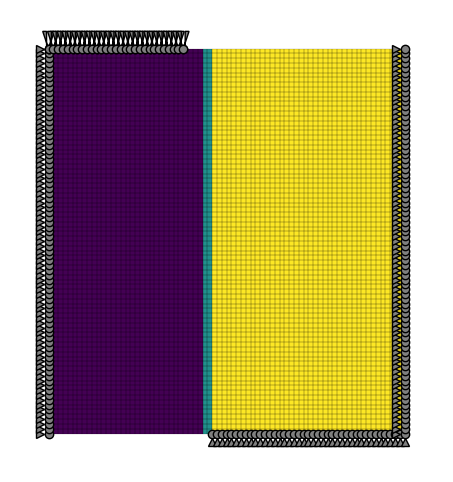

In [4]:
model = Axisymmetric(nodes, elements, material)

# Boundary conditions
model.constraints[axis, 0] = True
model.constraints[outer, 0] = True
model.constraints[support, 1] = True

# Indenter pushing the fiber down
U_MAX = 0.01
model.constraints[push, 1] = True
model.displacements[push, 1] = -U_MAX

phases = 1.0 * interphase + 2.0 * matrix
model.plot(element_property={"Phase": phases}, linewidth=0.1)

## Solve

The indenter is pushed to an increasing fraction of `U_MAX` and released again, so every cycle unloads from further along the softening branch. A damage model has an unsymmetric tangent, so the solver would pick BiCGSTAB at this size, where a direct solve is considerably faster.

In [5]:
# Ramp up to each peak and back down to zero
PEAKS = [0.3, 0.5, 1.0]
STEPS = 20

ramps = [torch.zeros(1)]
for peak in PEAKS:
    ramps.append(torch.linspace(0.0, peak, STEPS + 1)[1:])
    ramps.append(torch.linspace(peak, 0.0, STEPS + 1)[1:])

u, f, _, _, alpha = model.solve(
    increments=torch.cat(ramps),
    return_intermediate=True,
    verbose=True,
    method="direct",
)

----------------------------------------------------------------------------------------
 model    Axisymmetric | 5,920 elem | 12,150 dof | float64
 machine  Apple M1 Pro | 8 threads | 16 GB RAM
 solver   direct | scipy | cpu
 newton   rtol 1e-08 | atol 1e-06 | <=10 it
----------------------------------------------------------------------------------------
   Increment   Load factor      Steps  Iterations         Residual   Wall time
           1         0.015          1           1         4.08e-11      0.15 s
           2          0.03          1           0         8.17e-11      0.04 s
           3         0.045          1           0         1.23e-10      0.04 s
           4          0.06          1           0         1.63e-10      0.04 s
           5         0.075          1           0         2.04e-10      0.04 s
           6          0.09          1           0         2.45e-10      0.04 s
           7         0.105          1           0         2.86e-10      0.04 s
         

/Users/meyernil/Code/torch-fem/src/torchfem/sparse.py:504: MatrixRankWarning: Matrix is exactly singular
  return scipy_spsolve(A_np, b_np), None


## Postprocessing

The debond starts at the indented end and runs down the fiber. The load peaks with the debond about half way along, then drops as it runs out to the far end and settles at the sliding resistance the damaged interphase still carries. Damage localizes in the element layer on the fiber side, while fiber and matrix stay undamaged.

Each cycle unloads along a straight secant to the origin and reloads along it, since scalar damage degrades the stiffness without leaving a permanent strain.

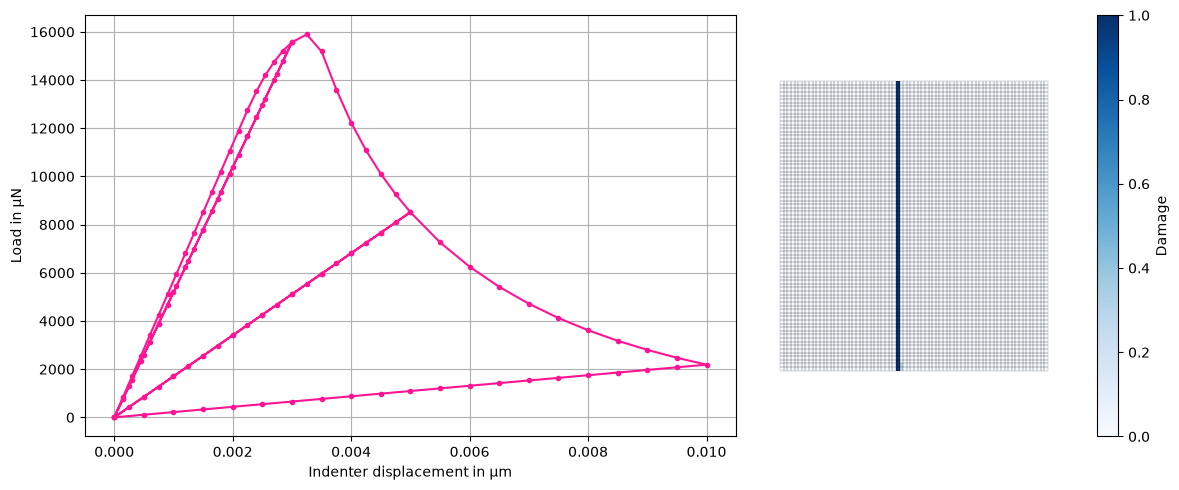

In [6]:
disp = u[:, push, 1].mean(dim=1).abs()
load = f[:, push, 1].sum(dim=1).abs()

fig, ax = plt.subplots(1, 2, figsize=(12, 5), width_ratios=[1.6, 1])
ax[0].plot(disp, load, ".-", color="deeppink")
ax[0].set_xlabel("Indenter displacement in µm")
ax[0].set_ylabel("Load in µN")
ax[0].grid()

model.plot(
    element_property={"Damage": alpha[-1, :, 1]},
    cmap="Blues",
    vmin=0.0,
    vmax=1.0,
    colorbar=True,
    linewidth=0.1,
    bcs=False,
    ax=ax[1],
)
plt.tight_layout()
plt.show()